## Data Understanding

## Objective

The aim of this dataset called New York taxi fare based on the airports mentioned in the data dataset is to provide a comprehensive collection of data on taxi rides within New York City. This dataset is valuable for analyzing and understanding various factors influencing taxi fare amounts, enabling researchers and analysts to develop models that accurately predict fare costs based on relevant input features.



## Data Explaining 

The dataset contains several columns with information about taxi service.The detailed data is given below:

* <code>'User ID'</code>: A unique identifier for each user.
* <code>'User Name'</code>: The name of the user.
* <code>'Driver Name'</code>: The name of the taxi driver.
* <code>'Car Condition'</code>: The condition of the taxi car.
* <code>'Weather'</code>: Information about the weather conditions during the trip.
* <code>'Traffic Condition'</code>: Information about the traffic conditions during the trip.
* <code>'key'</code>: A unique identifier for each trip.
* <code>'fare_amount'</code>: The fare amount charged for the trip.
* <code>'pickup_datetime'</code>: The date and time when the trip started.
* <code>'pickup_longitude'</code>: The longitude coordinate of the pickup location.
* <code>'pickup_latitude'</code>: The latitude coordinate of the pickup location.
* <code>'dropoff_longitude'</code>: The longitude coordinate of the dropoff location.
* <code>'dropoff_latitude'</code>: The latitude coordinate of the dropoff location.
* <code>'passenger_count'</code>: The number of passengers in the taxi.
* <code>'hour'</code>: The hour of the day when the trip started.
* <code>'day'</code>: The day of the month when the trip started.
* <code>'month'</code>: The month when the trip started.
* <code>'weekday'</code>: The day of the week when the trip started.
* <code>'year'</code>: The year when the trip started.
* <code>'jfk_dist'</code>: The distance from the pickup location to John F. Kennedy International Airport.
* <code>'ewr_dist'</code>: The distance from the pickup location to Newark Liberty International Airport.
* <code>'lga_dist'</code>: The distance from the pickup location to LaGuardia Airport.
* <code>'sol_dist'</code>: The distance from the pickup location to Statue of Liberty.
* <code>'nyc_dist'</code>: The distance from the pickup location to the center of New York City.
* <code>'distance'</code>: The total distance of the trip.
* <code>'bearing'</code>: The direction of travel from the pickup point to the dropoff point.

In [1]:
import numpy as np  # Linear algebra
import pandas as pd  # Data processing
import matplotlib.pyplot as plt  # Visualization
import seaborn as sns  # Statistical Data Visualization
import math  # Mathematical operations
import folium  # Interactive map visualization
import plotly.offline as offline  # Interactive visualization
import plotly.graph_objs as go  # Graph objects for Plotly
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder
from datetime import datetime

In [2]:
# Set theme for seaborn
sns.set_theme(style='darkgrid')

In [3]:
# Load dataset
df = pd.read_csv('/kaggle/input/uberdata/final_internship_data.csv')

In [4]:
# Display the first few rows
df.head()

,User ID,User Name,Driver Name,Car Condition,Weather,Traffic Condition,key,fare_amount,pickup_datetime,pickup_longitude,...,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
0,KHVrEVlD,Kimberly Adams,Amy Butler,Very Good,windy,Congested Traffic,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21,-1.288826,...,6,0,2009,20.265840,55.176046,14.342611,34.543548,27.572573,1.030764,-2.918897
1,lPxIuEri,Justin Tapia,Hannah Zimmerman,Excellent,cloudy,Flow Traffic,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16,-1.291824,...,1,1,2010,44.667679,31.832358,23.130775,15.125872,8.755732,8.450134,-0.375217
2,gsVN8JLS,Elizabeth Lopez,Amanda Jackson,Bad,stormy,Congested Traffic,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00,-1.291242,...,8,3,2011,43.597686,33.712082,19.865289,17.722624,9.847344,1.389525,2.599961
3,9I7kWFgd,Steven Wilson,Amy Horn,Very Good,stormy,Flow Traffic,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42,-1.291319,...,4,5,2012,42.642965,32.556289,21.063132,15.738963,7.703421,2.799270,0.133905
4,8QN5ZaGN,Alexander Andrews,Cassandra Larson,Bad,stormy,Congested Traffic,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00,-1.290987,...,3,1,2010,43.329953,39.406828,15.219339,23.732406,15.600745,1.999157,-0.502703


In [5]:
df.shape

(500000, 26)

We notice in the <code>fare_amount</code> that there is a negative value in min we need to fix it and we have another issue in <code>passenger_count</code> and <code>distance</code> which contains zero counts we will fix this also.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 26 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   User ID            500000 non-null  object 
 1   User Name          500000 non-null  object 
 2   Driver Name        500000 non-null  object 
 3   Car Condition      500000 non-null  object 
 4   Weather            500000 non-null  object 
 5   Traffic Condition  500000 non-null  object 
 6   key                500000 non-null  object 
 7   fare_amount        500000 non-null  float64
 8   pickup_datetime    500000 non-null  object 
 9   pickup_longitude   500000 non-null  float64
 10  pickup_latitude    500000 non-null  float64
 11  dropoff_longitude  499995 non-null  float64
 12  dropoff_latitude   499995 non-null  float64
 13  passenger_count    500000 non-null  int64  
 14  hour               500000 non-null  int64  
 15  day                500000 non-null  int64  
 16  mo

In [8]:
# Check for missing values
df.isnull().sum()

User ID              0
User Name            0
Driver Name          0
Car Condition        0
Weather              0
Traffic Condition    0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    5
dropoff_latitude     5
passenger_count      0
hour                 0
day                  0
month                0
weekday              0
year                 0
jfk_dist             5
ewr_dist             5
lga_dist             5
sol_dist             5
nyc_dist             5
distance             5
bearing              5
dtype: int64

There are some null values and there are small I will drop them with <code>User ID</code> column.

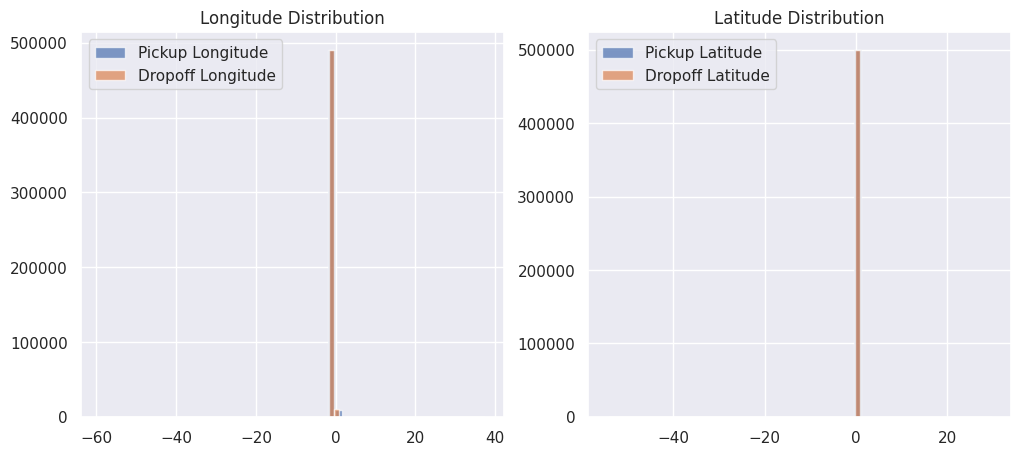

In [9]:
# Visualizing longitude and latitude distributions to ensure validity
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
axes[0].hist(df['pickup_longitude'], bins=50, alpha=0.7, label='Pickup Longitude')
axes[0].hist(df['dropoff_longitude'], bins=50, alpha=0.7, label='Dropoff Longitude')
axes[0].set_title("Longitude Distribution")
axes[0].legend()
    
axes[1].hist(df['pickup_latitude'], bins=50, alpha=0.7, label='Pickup Latitude')
axes[1].hist(df['dropoff_latitude'], bins=50, alpha=0.7, label='Dropoff Latitude')
axes[1].set_title("Latitude Distribution")
axes[1].legend()
    
plt.show()

In [10]:
# Drop entirely invalid longitude & latitude columns
#df.drop(['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude'], axis=1, inplace=True)

In [11]:
# Drop 'User ID' column as it is not useful for analysis
df.drop(columns="User ID", axis=1, inplace=True)


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 25 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   User Name          500000 non-null  object 
 1   Driver Name        500000 non-null  object 
 2   Car Condition      500000 non-null  object 
 3   Weather            500000 non-null  object 
 4   Traffic Condition  500000 non-null  object 
 5   key                500000 non-null  object 
 6   fare_amount        500000 non-null  float64
 7   pickup_datetime    500000 non-null  object 
 8   pickup_longitude   500000 non-null  float64
 9   pickup_latitude    500000 non-null  float64
 10  dropoff_longitude  499995 non-null  float64
 11  dropoff_latitude   499995 non-null  float64
 12  passenger_count    500000 non-null  int64  
 13  hour               500000 non-null  int64  
 14  day                500000 non-null  int64  
 15  month              500000 non-null  int64  
 16  we

We will replace zero count passenger with 1 and will filter out the 0 distance from the dataframe

In [13]:
df['passenger_count'].value_counts()

passenger_count
1    346009
2     73908
5     35322
3     21761
4     10614
6     10590
0      1796
Name: count, dtype: int64

In [14]:
# Handling passenger count: Replace zero passengers with 1
df['passenger_count'] = df['passenger_count'].apply(lambda x: 1 if x == 0 else x)

In [15]:
df['passenger_count'].value_counts()

passenger_count
1    347805
2     73908
5     35322
3     21761
4     10614
6     10590
Name: count, dtype: int64

In [16]:
# Drop rows with missing values in distance metrics
df.dropna(inplace=True)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 499995 entries, 0 to 499999
Data columns (total 25 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   User Name          499995 non-null  object 
 1   Driver Name        499995 non-null  object 
 2   Car Condition      499995 non-null  object 
 3   Weather            499995 non-null  object 
 4   Traffic Condition  499995 non-null  object 
 5   key                499995 non-null  object 
 6   fare_amount        499995 non-null  float64
 7   pickup_datetime    499995 non-null  object 
 8   pickup_longitude   499995 non-null  float64
 9   pickup_latitude    499995 non-null  float64
 10  dropoff_longitude  499995 non-null  float64
 11  dropoff_latitude   499995 non-null  float64
 12  passenger_count    499995 non-null  int64  
 13  hour               499995 non-null  int64  
 14  day                499995 non-null  int64  
 15  month              499995 non-null  int64  
 16  weekday

In [18]:
len(df[df['fare_amount'] < 0]) # number of records that contain negative values

21

In [19]:
len(df[df['fare_amount'] == 0]) # number of records that contain zero value

14

In [20]:
# Remove extreme fare values
df.drop(df[(df['fare_amount'] > 200) | (df['fare_amount'] < 2.5)].index, inplace=True)

# Print the length of the filtered DataFrame
print(len(df))


499928


In [21]:
# Print summary statistics
df.describe()


,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,weekday,year,jfk_dist,ewr_dist,lga_dist,sol_dist,nyc_dist,distance,bearing
count,499928.000000,499928.000000,499928.000000,499928.000000,499928.000000,499928.000000,499928.000000,499928.000000,499928.000000,499928.000000,499928.000000,499928.000000,499928.000000,499928.000000,499928.000000,499928.000000,499928.000000,499928.000000
mean,11.345051,-1.265721,0.696745,-1.265768,0.696681,1.687049,13.511046,15.684151,6.268839,3.042018,2011.738916,385.151532,380.373783,363.714820,363.543977,355.861184,19.435610,0.297165
std,9.686587,0.206917,0.140902,0.205870,0.128983,1.304169,6.511503,8.681129,3.437823,1.949246,1.860801,2418.717389,2428.432834,2424.704769,2427.976936,2428.359062,366.917776,1.804562
min,2.500000,-52.119764,-54.389440,-59.049665,-44.676047,1.000000,0.000000,1.000000,1.000000,0.000000,2009.000000,1.017646,1.460945,0.382119,0.532545,0.080500,0.000000,-3.141593
25%,6.000000,-1.291405,0.710958,-1.291393,0.710943,1.000000,9.000000,8.000000,3.000000,1.000000,2010.000000,41.341573,32.173555,17.100767,14.886837,7.147109,1.214815,-0.854738
50%,8.500000,-1.291226,0.711268,-1.291197,0.711277,1.000000,14.000000,16.000000,6.000000,3.000000,2012.000000,42.523112,34.787268,19.591464,18.347027,10.457758,2.117150,-0.050486
75%,12.500000,-1.290970,0.711520,-1.290908,0.711538,2.000000,19.000000,23.000000,9.000000,5.000000,2013.000000,43.785387,38.303650,22.214253,22.416672,14.447452,3.890186,2.206834
max,200.000000,37.360538,29.724576,0.712985,7.061893,6.000000,23.000000,31.000000,12.000000,6.000000,2015.000000,30133.067880,30167.595967,30167.285794,30159.407296,30162.285356,12399.956433,3.141593


In [22]:
# Outlier detection and removal based on ride distance
df = df[(df['distance'] > 0) & (df['distance'] <= 200)]

In [23]:
print(df.shape)  # Should show (number of rows, number of columns)


(484685, 25)


In [24]:
 # Cap unrealistic airport distances using IQR method
for col in ['jfk_dist', 'ewr_dist', 'lga_dist']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr  # Allow some variation
    df = df[df[col] <= upper_bound]

In [25]:
print(df.shape)  # Should show (number of rows, number of columns)


(453613, 25)


In [26]:
# Convert pickup_datetime to datetime format
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

In [27]:
print(df.shape)  # Should show (number of rows, number of columns)


(453613, 25)


In [28]:
# Feature Engineering: Extract time-based features
df['minute'] = df['pickup_datetime'].dt.minute
df['day_of_year'] = df['pickup_datetime'].dt.dayofyear
df['quarter'] = df['pickup_datetime'].dt.quarter
df['time_of_day'] = df['pickup_datetime'].dt.hour.apply(lambda x: 'Night' if x < 6 else ('Morning' if x < 12 else ('Afternoon' if x < 18 else 'Evening')))
df['rush_hour'] = df['pickup_datetime'].dt.hour.apply(lambda x: 1 if (7 <= x <= 9 or 16 <= x <= 19) else 0)
df['weekend'] = df['pickup_datetime'].dt.weekday.apply(lambda x: 1 if x in [5, 6] else 0)

In [29]:
print(df.shape)  # Should show (number of rows, number of columns)


(453613, 31)


In [30]:
# Drop original datetime columns
df.drop(['pickup_datetime'], axis=1, inplace=True)

In [31]:
print(df.shape)  # Should show (number of rows, number of columns)

(453613, 30)


In [32]:
# Bin distance into categories
bins = [0, 2, 5, 10, 20, 50, 200]
labels = ['Very Short', 'Short', 'Medium', 'Long', 'Very Long', 'Extreme']
df['distance_bin'] = pd.cut(df['distance'], bins=bins, labels=labels)

In [33]:
# Compute price per mile
df['price_per_mile'] = df['fare_amount'] / df['distance']

In [34]:
for col in df.select_dtypes(include=['object', 'category']).columns:
    print(f"{col} unique values: {df[col].unique()}")


User Name unique values: ['Justin Tapia' 'Elizabeth Lopez' 'Steven Wilson' ... 'Monique Wade'
 'Wanda Parks' 'Dillon Jackson']
Driver Name unique values: ['Hannah Zimmerman' 'Amanda Jackson' 'Amy Horn' ... 'Gabriel Coleman'
 'Larry Richards' 'Lonnie Santana']
Car Condition unique values: ['Excellent' 'Bad' 'Very Good' 'Good']
Weather unique values: ['cloudy' 'stormy' 'sunny' 'windy' 'rainy']
Traffic Condition unique values: ['Flow Traffic' 'Congested Traffic' 'Dense Traffic']
key unique values: ['2010-01-05 16:52:16.0000002' '2011-08-18 00:35:00.00000049'
 '2012-04-21 04:30:42.0000001' ... '2014-08-25 00:22:20.0000001'
 '2015-01-12 12:17:32.0000001' '2010-04-12 23:46:58.0000002']
time_of_day unique values: ['Afternoon' 'Night' 'Morning' 'Evening']
distance_bin unique values: ['Medium', 'Very Short', 'Short', 'Long', 'Very Long']
Categories (6, object): ['Very Short' < 'Short' < 'Medium' < 'Long' < 'Very Long' < 'Extreme']


In [35]:
    # Handle categorical encoding
ordinal_features = {'Car Condition': ['Bad', 'Average', 'Good', 'Very Good', 'Excellent'],
                        'Traffic Condition': ['Flow Traffic', 'Dense Traffic', 'Congested Traffic'],
                        'distance_bin': ['Very Short', 'Short', 'Medium', 'Long', 'Very Long', 'Extreme']}
    
ordinal_encoder = OrdinalEncoder(categories=[ordinal_features[col] for col in ordinal_features], handle_unknown='use_encoded_value', unknown_value=-1)
df[list(ordinal_features.keys())] = ordinal_encoder.fit_transform(df[list(ordinal_features.keys())])

In [36]:
# One-hot encoding for unordered categorical variables
#df = pd.get_dummies(df, columns=['Weather', 'time_of_day'], drop_first=True)

In [37]:
# Cyclical encoding for time features
df['minute_sin'] = np.sin(2 * np.pi * df['minute'] / 60)
df['minute_cos'] = np.cos(2 * np.pi * df['minute'] / 60)
df['day_of_year_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['day_of_year_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)

In [38]:
# Drop redundant columns
df.drop(['minute', 'day_of_year'], axis=1, inplace=True)

In [40]:
# Check for missing values
df.isnull().sum()

User Name            0
Driver Name          0
Car Condition        0
Weather              0
Traffic Condition    0
key                  0
fare_amount          0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
hour                 0
day                  0
month                0
weekday              0
year                 0
jfk_dist             0
ewr_dist             0
lga_dist             0
sol_dist             0
nyc_dist             0
distance             0
bearing              0
quarter              0
time_of_day          0
rush_hour            0
weekend              0
distance_bin         0
price_per_mile       0
minute_sin           0
minute_cos           0
day_of_year_sin      0
day_of_year_cos      0
dtype: int64

# Data Visualisation

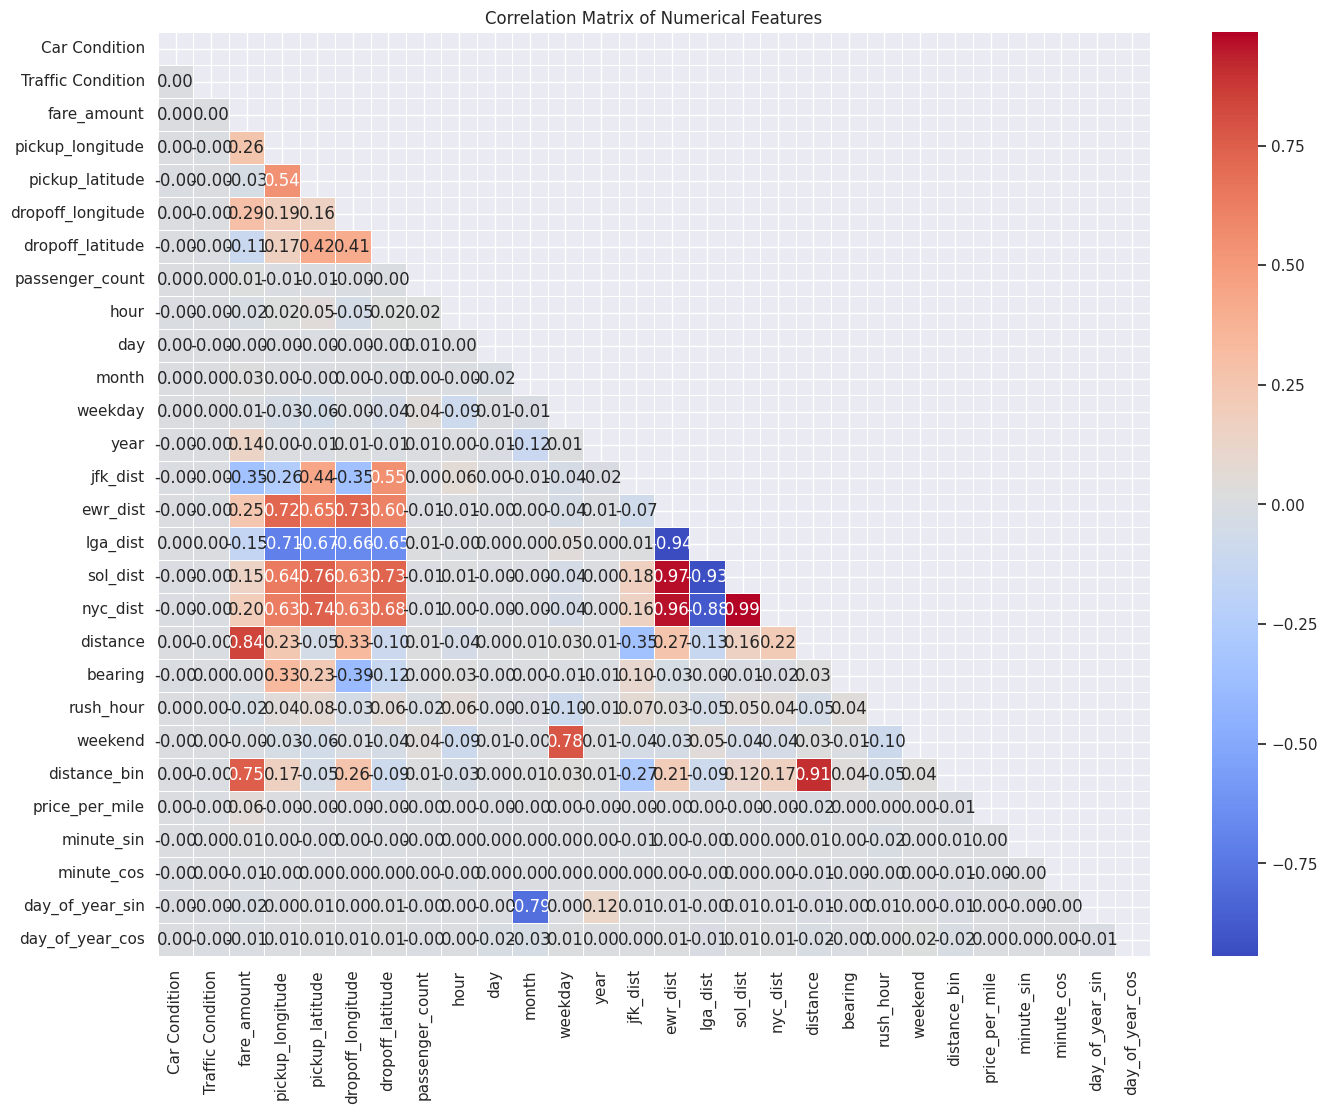

In [41]:
# Correlation matrix for numerical features
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(correlation_matrix)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, mask=mask)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

we can see a lot of correlation between distance and longitude this is because the distance itself uses the longitude and latitude to be calculated.

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



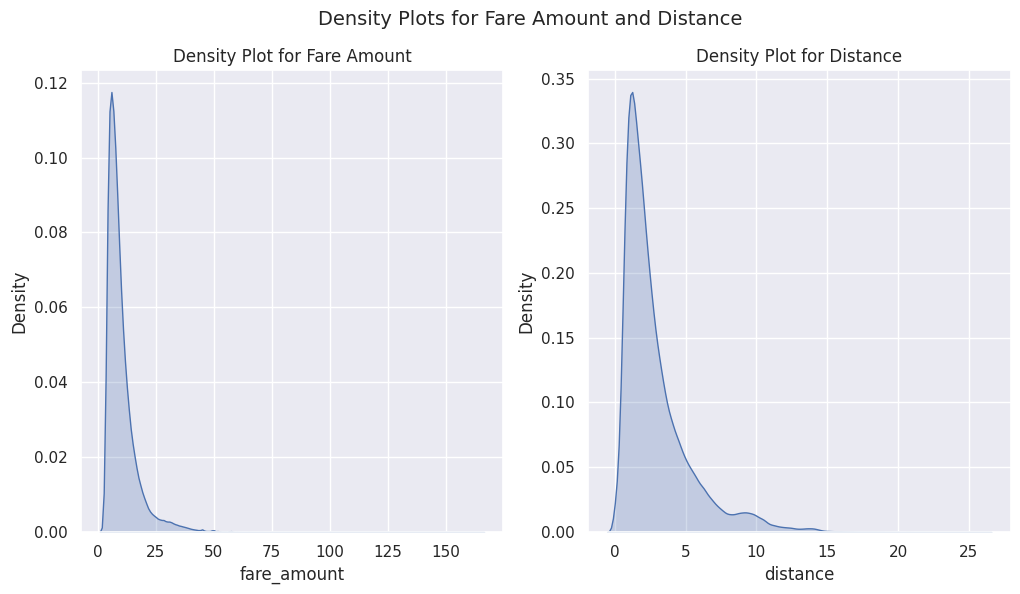

In [42]:
# Density plots for fare_amount and distance
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.kdeplot(data=df['fare_amount'], ax=axes[0], fill=True)
axes[0].set_title('Density Plot for Fare Amount')

sns.kdeplot(data=df['distance'], ax=axes[1], fill=True)
axes[1].set_title('Density Plot for Distance')

plt.suptitle('Density Plots for Fare Amount and Distance', fontsize=14)
plt.show()

In [43]:
# Top correlations with fare_amount
fare_correlations = correlation_matrix['fare_amount'].sort_values(ascending=False)
print("Top correlations with fare_amount:")
display(fare_correlations)

Top correlations with fare_amount:


fare_amount          1.000000
distance             0.836573
distance_bin         0.752077
dropoff_longitude    0.287779
pickup_longitude     0.256053
ewr_dist             0.250378
nyc_dist             0.195559
sol_dist             0.149787
year                 0.137984
price_per_mile       0.055798
month                0.029244
passenger_count      0.014273
minute_sin           0.007681
weekday              0.006339
Car Condition        0.003165
bearing              0.001226
Traffic Condition    0.000440
day                 -0.000749
weekend             -0.004893
minute_cos          -0.007139
day_of_year_cos     -0.007884
hour                -0.018478
day_of_year_sin     -0.018876
rush_hour           -0.024458
pickup_latitude     -0.030241
dropoff_latitude    -0.112603
lga_dist            -0.147364
jfk_dist            -0.346789
Name: fare_amount, dtype: float64

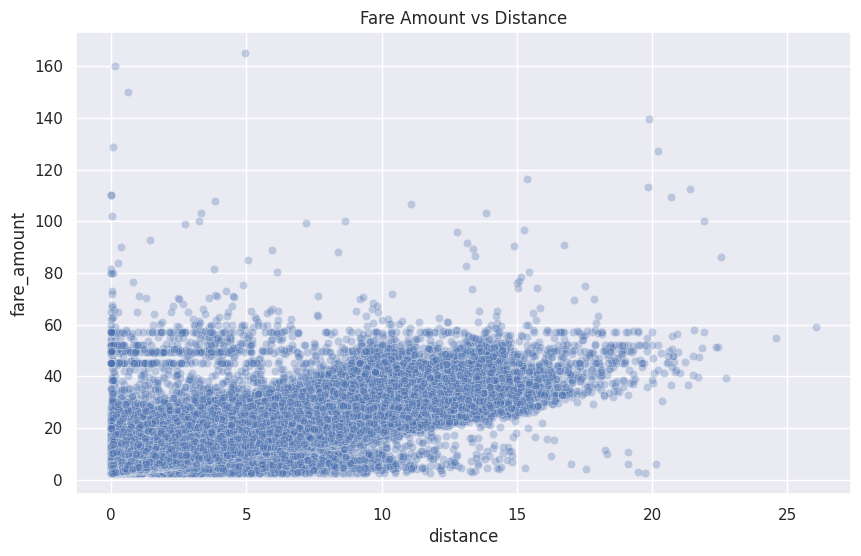

In [44]:
# Scatter plots for key relationships
plt.figure(figsize=(10, 6))
sns.scatterplot(x='distance', y='fare_amount', data=df, alpha=0.3)
plt.title('Fare Amount vs Distance')
plt.show()

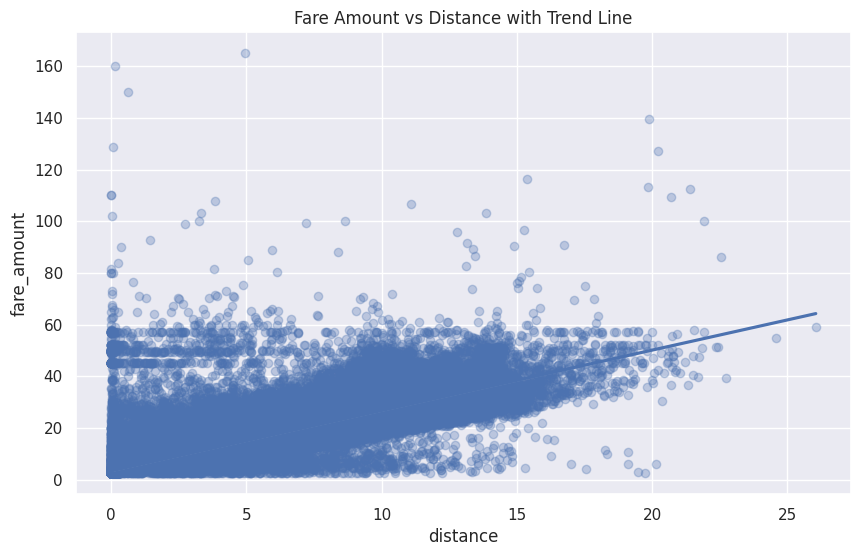

In [45]:
# Add regression line to see trend
plt.figure(figsize=(10, 6))
sns.regplot(x='distance', y='fare_amount', data=df, scatter_kws={'alpha':0.3})
plt.title('Fare Amount vs Distance with Trend Line')
plt.show()

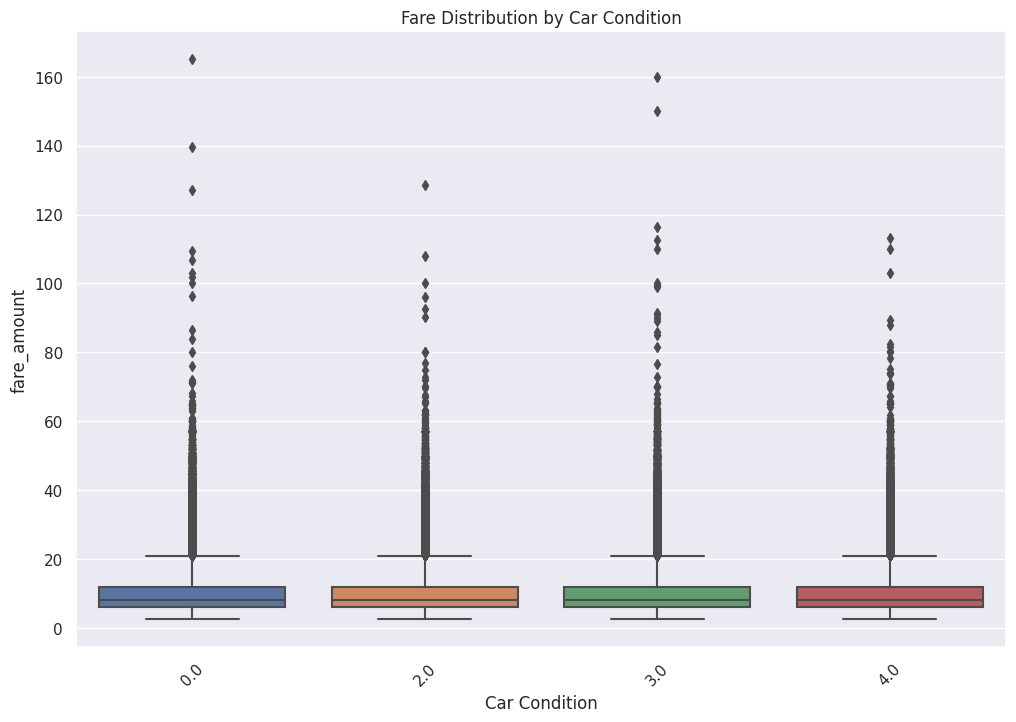


Mean fare by Car Condition:
3.0: $10.17
4.0: $10.15
2.0: $10.14
0.0: $10.10


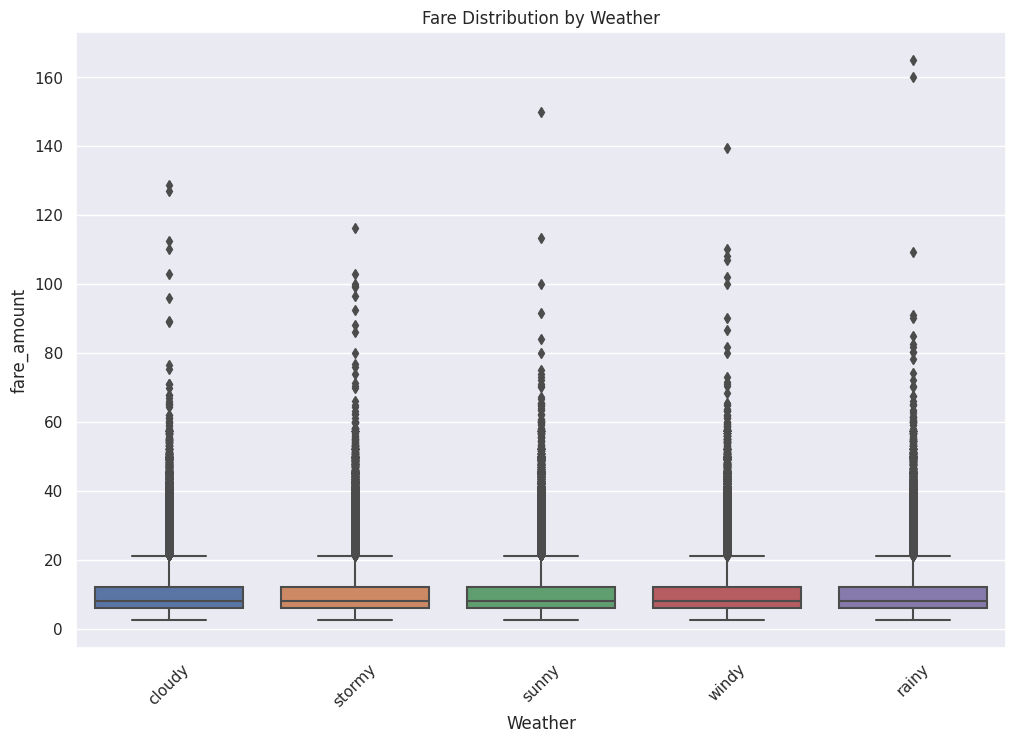


Mean fare by Weather:
cloudy: $10.15
stormy: $10.15
windy: $10.14
sunny: $10.14
rainy: $10.13


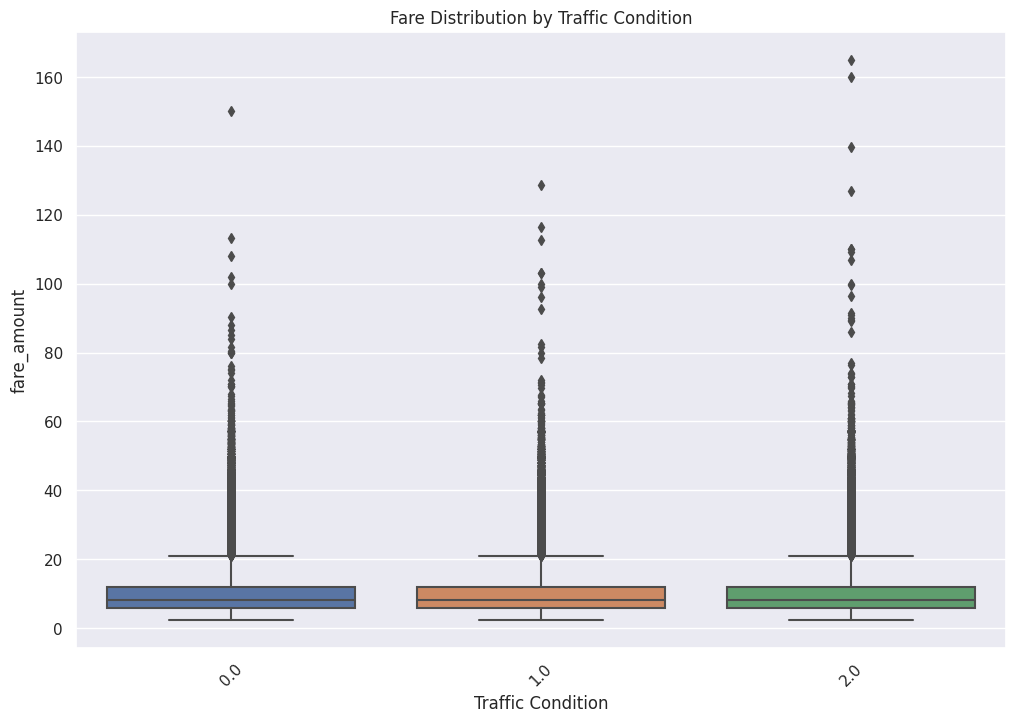


Mean fare by Traffic Condition:
1.0: $10.15
2.0: $10.14
0.0: $10.13


In [46]:
# Key categorical variable effects on fare_amount
for cat_var in ['Car Condition', 'Weather', 'Traffic Condition']:
    plt.figure(figsize=(12, 8))
    sns.boxplot(x=cat_var, y='fare_amount', data=df)
    plt.title(f'Fare Distribution by {cat_var}')
    plt.xticks(rotation=45)
    plt.show()
    
    # Calculate mean fare by category
    category_means = df.groupby(cat_var)['fare_amount'].mean().sort_values(ascending=False)
    print(f"\nMean fare by {cat_var}:")
    for category, mean_fare in category_means.items():
        print(f"{category}: ${mean_fare:.2f}")

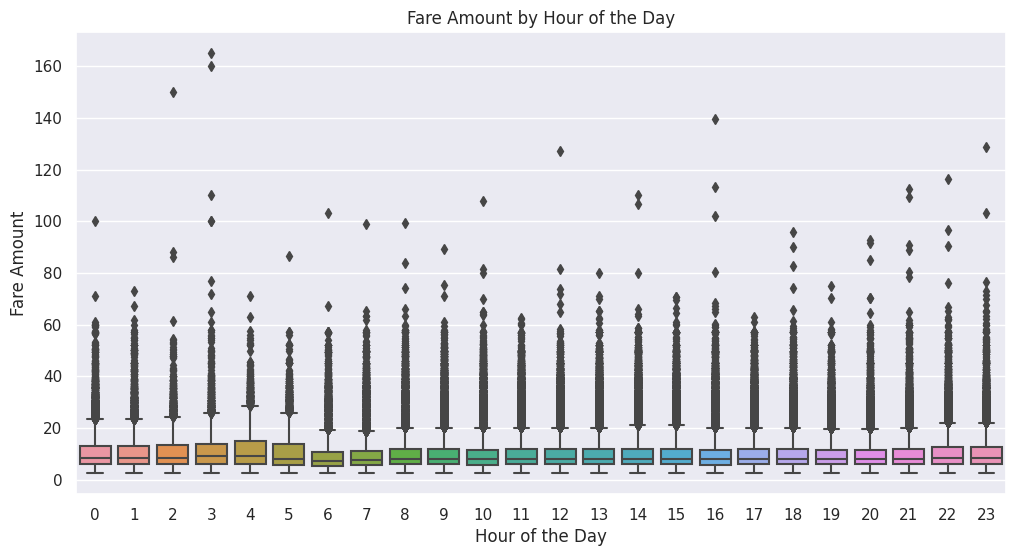

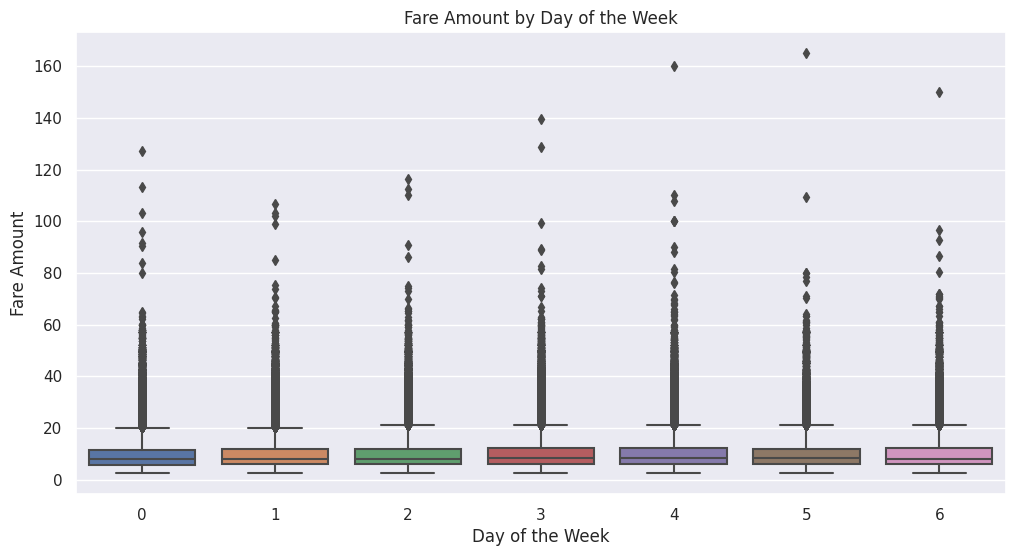

In [47]:
# Temporal Analysis
plt.figure(figsize=(12, 6))
sns.boxplot(x='hour', y='fare_amount', data=df)
plt.title('Fare Amount by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Fare Amount')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x='weekday', y='fare_amount', data=df)
plt.title('Fare Amount by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Fare Amount')
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



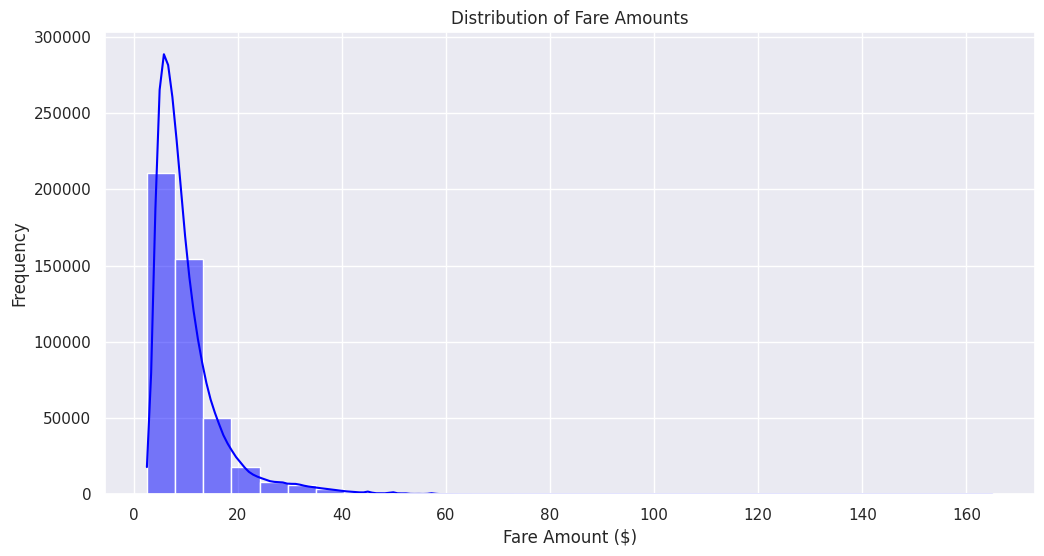

In [50]:
plt.figure(figsize=(12, 6))
sns.histplot(df['fare_amount'], bins=30, kde=True, color='blue')
plt.title('Distribution of Fare Amounts')
plt.xlabel('Fare Amount ($)')
plt.ylabel('Frequency')
plt.show()

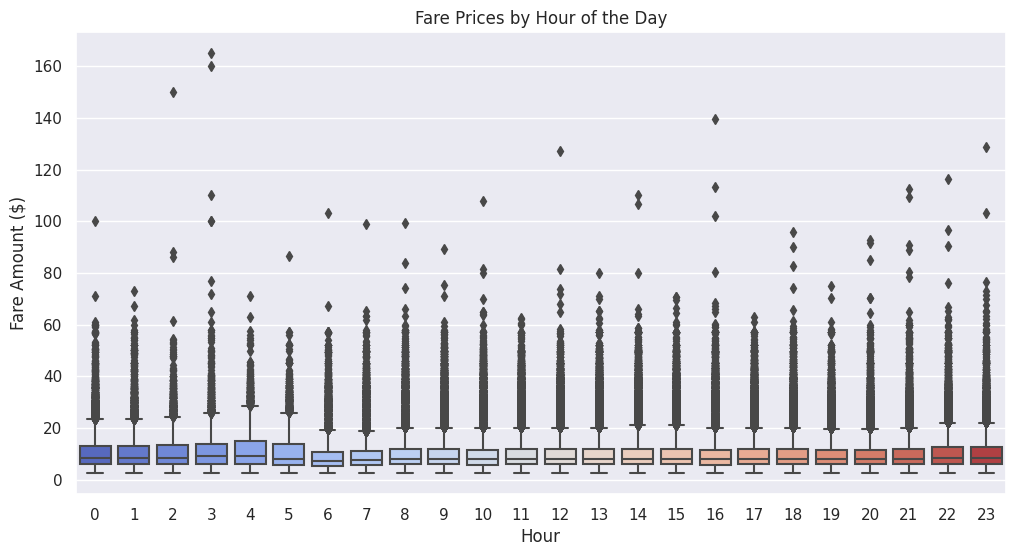

In [51]:
# Hourly trend of fare prices
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['hour'], y=df['fare_amount'], palette='coolwarm')
plt.title('Fare Prices by Hour of the Day')
plt.xlabel('Hour')
plt.ylabel('Fare Amount ($)')
plt.show()


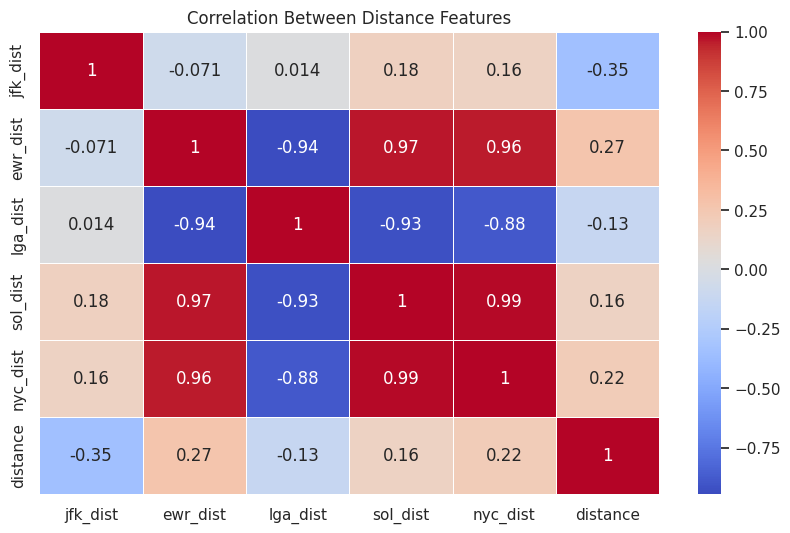

In [52]:
# Heatmap of distance relationships
distance_cols = ['jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'nyc_dist', 'distance']
plt.figure(figsize=(10, 6))
sns.heatmap(df[distance_cols].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Between Distance Features')
plt.show()

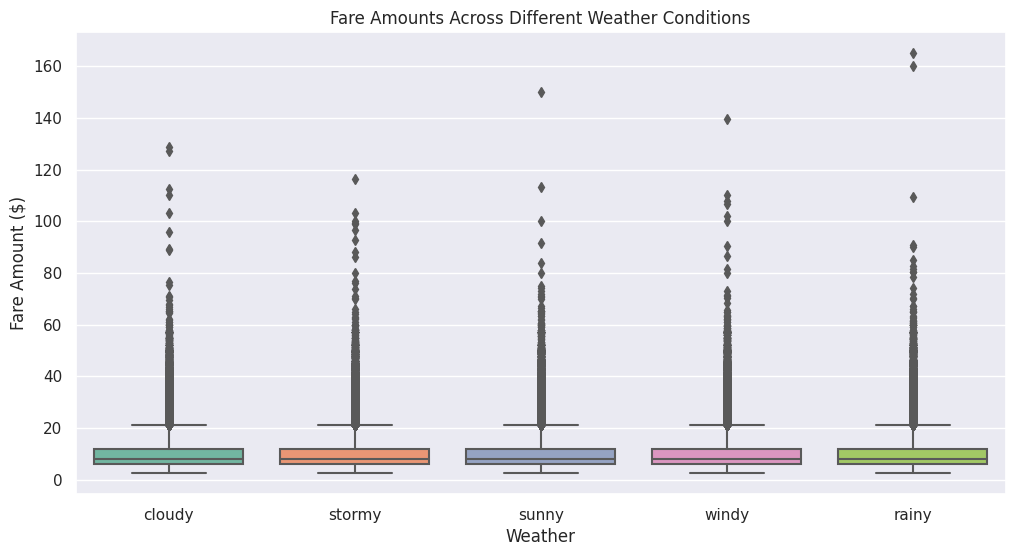

In [53]:
# Boxplot of fare distribution across different weather conditions
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['Weather'], y=df['fare_amount'], palette='Set2')
plt.title('Fare Amounts Across Different Weather Conditions')
plt.xlabel('Weather')
plt.ylabel('Fare Amount ($)')
plt.show()

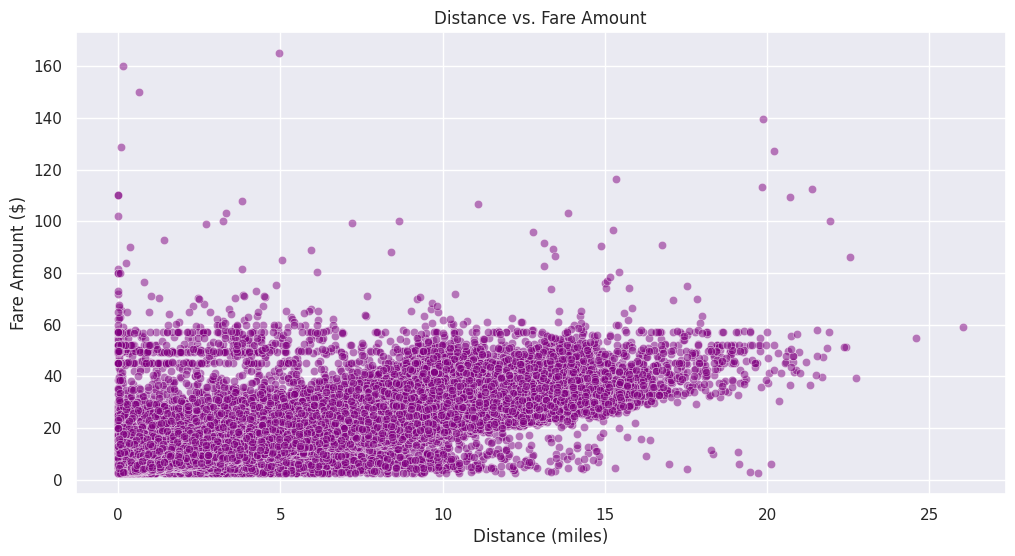

In [54]:
# Relationship between ride distance and fare amount
plt.figure(figsize=(12, 6))
sns.scatterplot(x=df['distance'], y=df['fare_amount'], alpha=0.5, color='purple')
plt.title('Distance vs. Fare Amount')
plt.xlabel('Distance (miles)')
plt.ylabel('Fare Amount ($)')
plt.show()


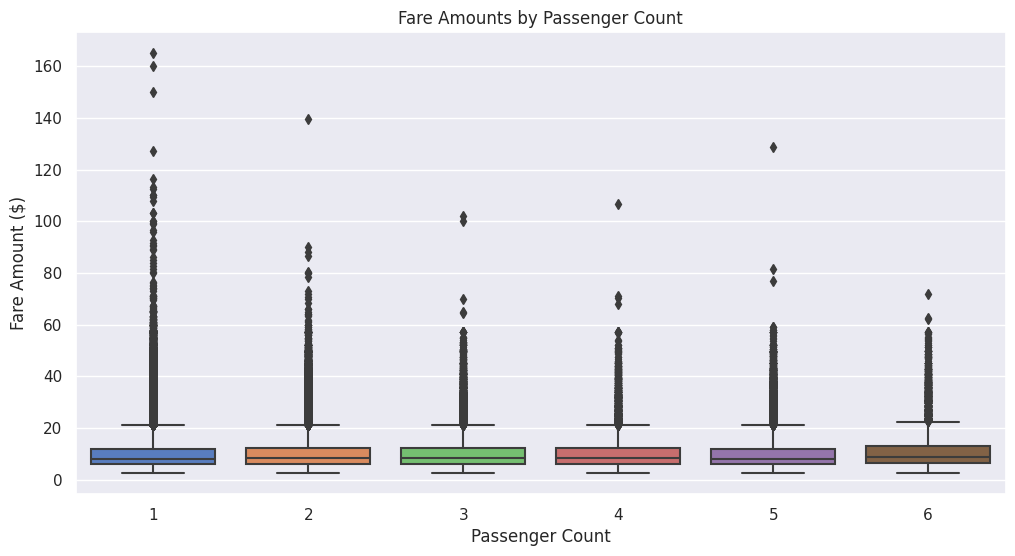

In [55]:
# New Visualization: Passenger count impact
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['passenger_count'], y=df['fare_amount'], palette='muted')
plt.title('Fare Amounts by Passenger Count')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount ($)')
plt.show()


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



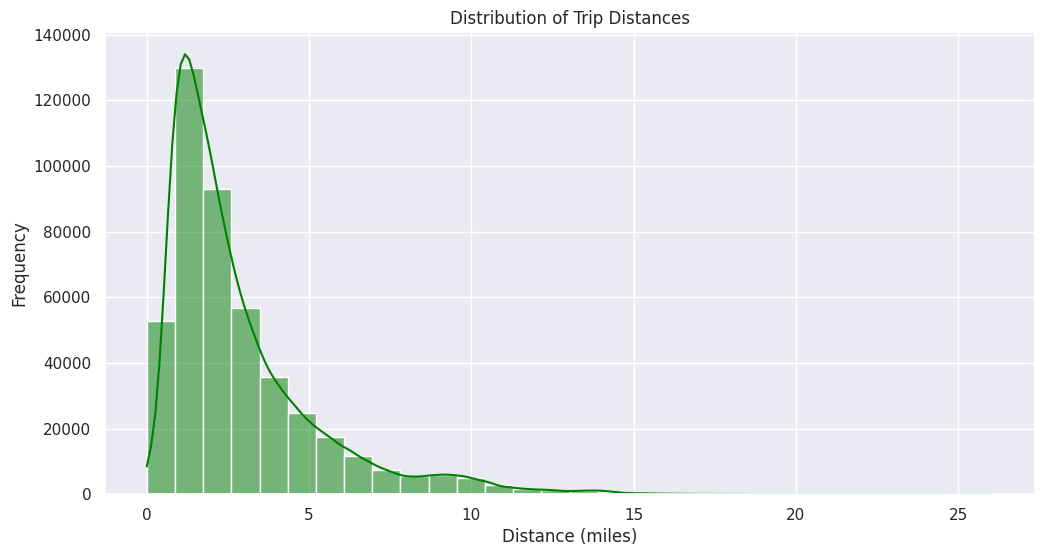

In [56]:
# New Visualization: Distribution of trip distances
plt.figure(figsize=(12, 6))
sns.histplot(df['distance'], bins=30, kde=True, color='green')
plt.title('Distribution of Trip Distances')
plt.xlabel('Distance (miles)')
plt.ylabel('Frequency')
plt.show()


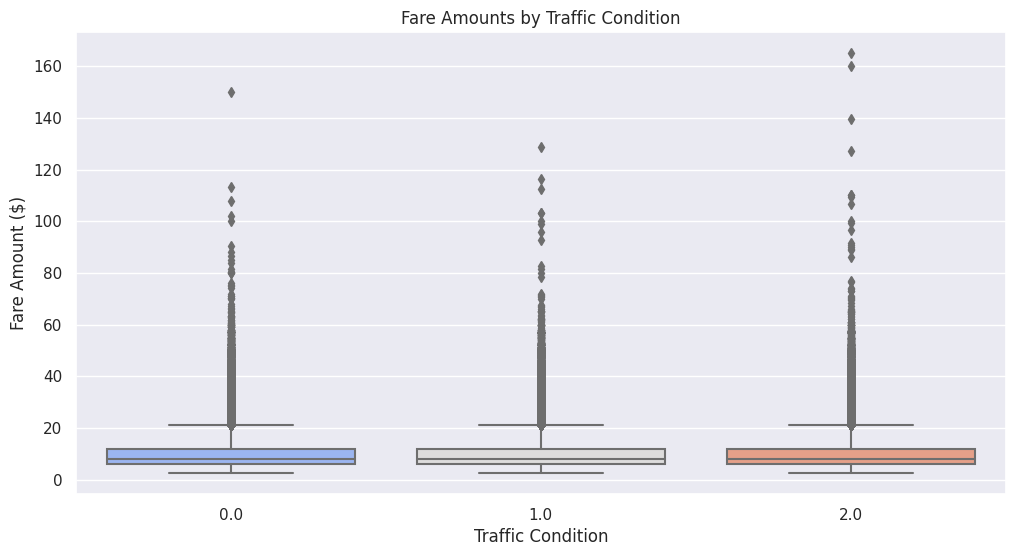

In [57]:
# New Visualization: Traffic condition impact
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['Traffic Condition'], y=df['fare_amount'], palette='coolwarm')
plt.title('Fare Amounts by Traffic Condition')
plt.xlabel('Traffic Condition')
plt.ylabel('Fare Amount ($)')
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1765: FutureWarning:

unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.



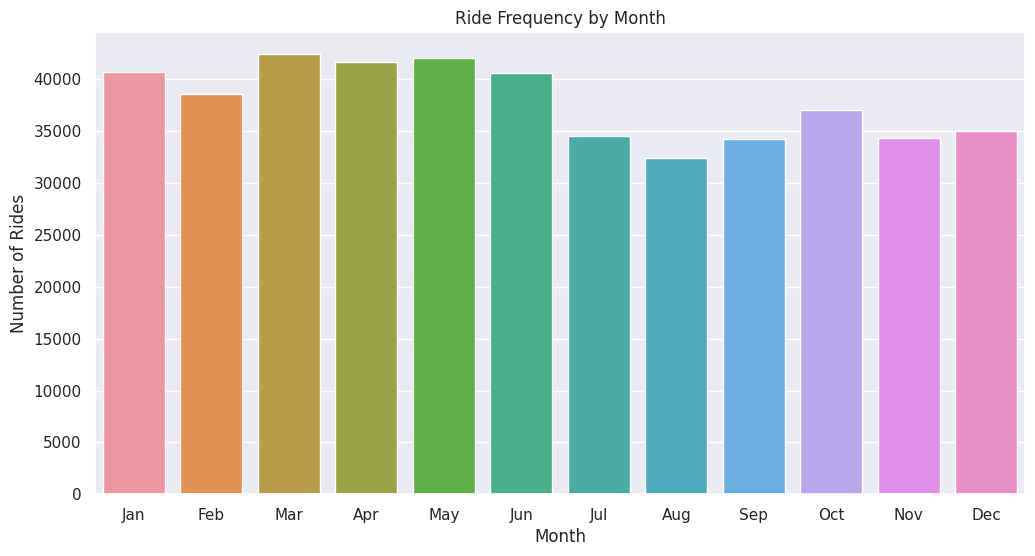

In [58]:
# Monthly patterns
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_counts = df.groupby('month').size()
plt.figure(figsize=(12, 6))
sns.barplot(x=[month_names[i-1] for i in range(1, 13)], y=[monthly_counts.get(i, 0) for i in range(1, 13)])
plt.title('Ride Frequency by Month')
plt.xlabel('Month')
plt.ylabel('Number of Rides')
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1765: FutureWarning:

unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.



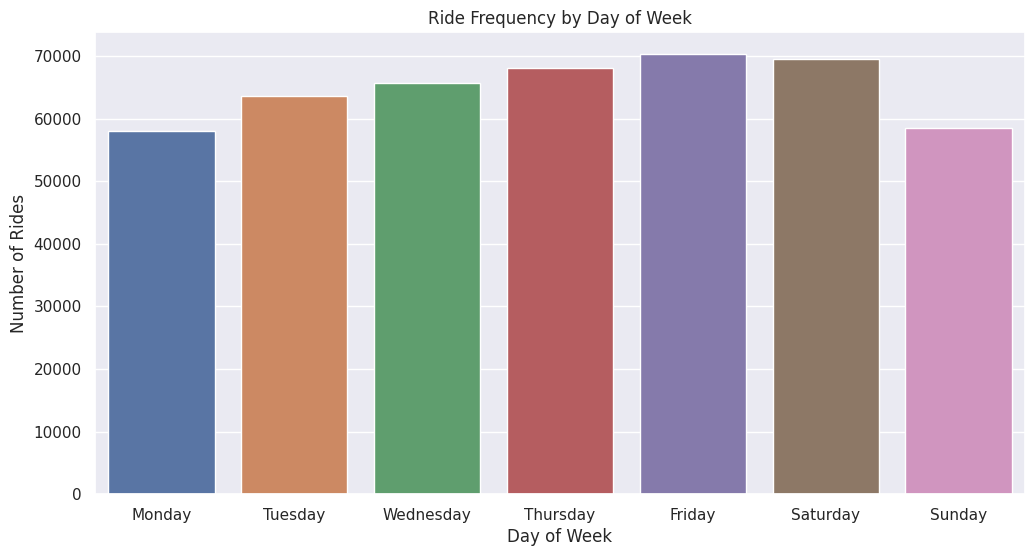

In [60]:
# Day of week patterns
weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_counts = df.groupby('weekday').size()
plt.figure(figsize=(12, 6))
sns.barplot(x=[weekday_names[i] for i in range(7)], y=[weekday_counts.get(i, 0) for i in range(7)])
plt.title('Ride Frequency by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Rides')
plt.show()


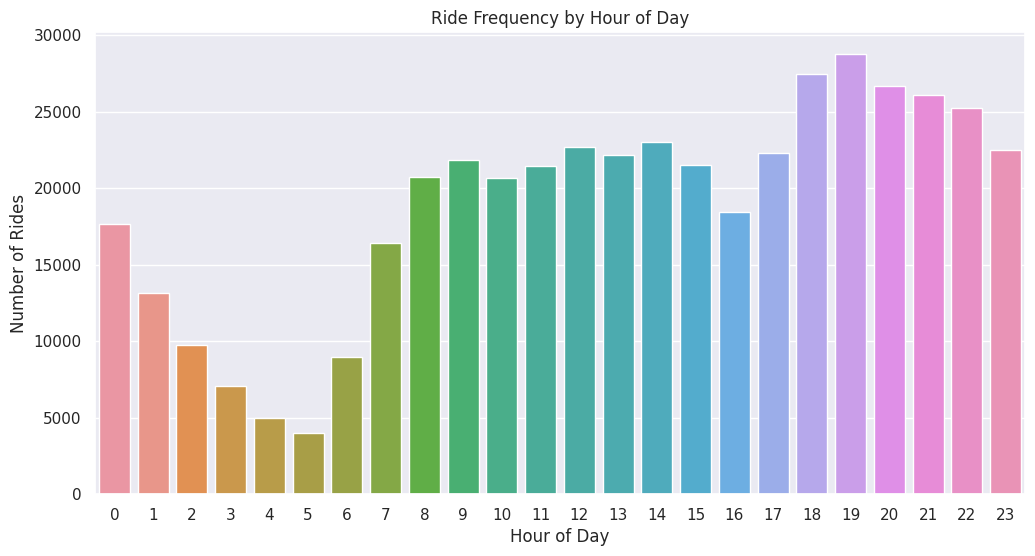

In [73]:
# Hour of day patterns
plt.figure(figsize=(12, 6))
hourly_counts = df.groupby('hour').size()
sns.barplot(x=hourly_counts.index, y=hourly_counts.values)
plt.title('Ride Frequency by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Rides')
plt.xticks(range(24))
plt.show()

In [91]:
# Filtering pickup latitude and longitude within NYC bounds
data = df.loc[df['pickup_latitude'].between(math.radians(40), math.radians(42))]
data = df.loc[df['pickup_longitude'].between(math.radians(-75), math.radians(-72))]
df2 = data

# Sample data for mapping
sample_data = df2.sample(n=500, random_state=42)

In [76]:
# Interactive Scatter Map for Pick-up Locations
df2 = [
    go.Scattermapbox(
        lat=sample_data['pickup_latitude'].apply(lambda x: math.degrees(x)),
        lon=sample_data['pickup_longitude'].apply(lambda x: math.degrees(x)),
        mode='markers',
        marker=dict(size=5, color='yellow', opacity=1),
    )
]

layout = go.Layout(
    autosize=False,
    mapbox=dict(
        bearing=10,
        pitch=60,
        zoom=13,
        center=dict(lat=40.721319, lon=-73.987130),
        style="mapbox://styles/shaz13/cjiog1iqa1vkd2soeu5eocy4i"
    ),
    width=900,
    height=600,
    title="Pick-up Locations in New York"
)

fig = dict(data=df2, layout=layout)
offline.iplot(fig)


In [ ]:
offline.init_notebook_mode()

df2 = data
sample = df2.sample(n=1000, random_state=42)
high_fares = sample[sample['fare_amount'] > sample['fare_amount'].quantile(0.95)]

high_fares.head()

In [78]:
offline.init_notebook_mode()

df2 = [
    go.Scattermapbox(
        lat=sample['pickup_latitude'].apply(lambda x: math.degrees(x)),
        lon=sample['pickup_longitude'].apply(lambda x: math.degrees(x)),
        customdata=high_fares['key'],
        mode='markers',
        marker=dict(
            size=6,
            color='violet',
            opacity=1
        ),
        name='high_fares_pick_up'
    ),
    go.Scattermapbox(
        lat=sample['dropoff_latitude'].apply(lambda x: math.degrees(x)),
        lon=sample['dropoff_longitude'].apply(lambda x: math.degrees(x)),
        customdata=high_fares['key'],
        mode='markers',
        marker=dict(
            size=6,
            color='yellow',
            opacity=1
        ),
        name='high_fares_drop_off'
    )
]

layout = go.Layout(
    autosize=False,
    mapbox=dict(
        accesstoken="pk.eyJ1Ijoic2hhejEzIiwiYSI6ImNqYXA3NjhmeDR4d3Iyd2w5M2phM3E2djQifQ.yyxsAzT94VGYYEEOhxy87w",
        bearing=10,
        pitch=60,
        zoom=13,
        center=dict(
            lat=40.721319,
            lon=-73.987130
        ),
        style="mapbox://styles/shaz13/cjk4wlc1s02bm2smsqd7qtjhs"
    ),
    width=900,
    height=600,
    title="High Fare Locations"
)

fig = dict(data=df2, layout=layout)
offline.iplot(fig)


In [79]:
df2 = data
sample = df2.sample(n=1000, random_state=42)

In [80]:


train=df

# Create a map of New York City
map_nyc = folium.Map(location=[40.7128, -74.0060], zoom_start=11)

# Iterate through the dataset and plot pickups and dropoffs
for index, row in train.iterrows():
    pickup = [math.degrees(row["pickup_latitude"]), math.degrees(row["pickup_longitude"])]
    dropoff = [math.degrees(row["dropoff_latitude"]), math.degrees(row["dropoff_longitude"])]

    # Plot pickup and dropoff locations
    for location, color, popup in [(pickup, "blue", "Pickup"), (dropoff, "red", "Dropoff")]:
        folium.Marker(
            location=location,
            popup=popup,
            icon=folium.Icon(color=color),
        ).add_to(map_nyc)

    # Break the loop after plotting the first 10 pickups and dropoffs
    if index >= 9:
        break

# Display the map
map_nyc


In [81]:
df['Car Condition'].value_counts()

Car Condition
3.0    113570
2.0    113415
0.0    113323
4.0    113305
Name: count, dtype: int64

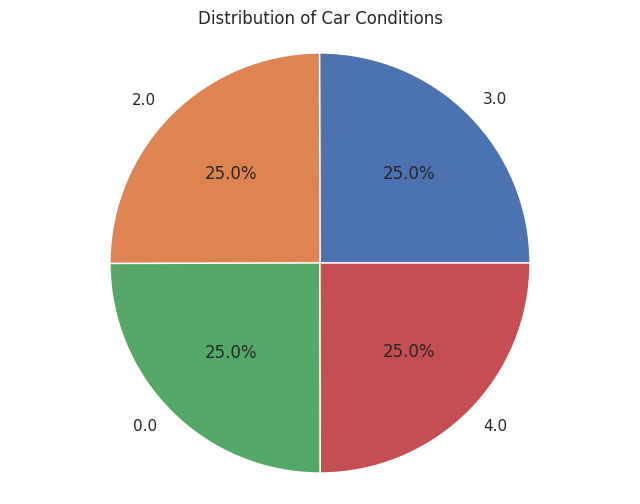

In [82]:
# Value counts for Car Condition
car_condition_counts = df['Car Condition'].value_counts()

# Plotting the pie chart
plt.figure(figsize=(8, 6))
plt.pie(car_condition_counts, labels=car_condition_counts.index, autopct='%1.1f%%', startangle=0)
plt.title('Distribution of Car Conditions')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


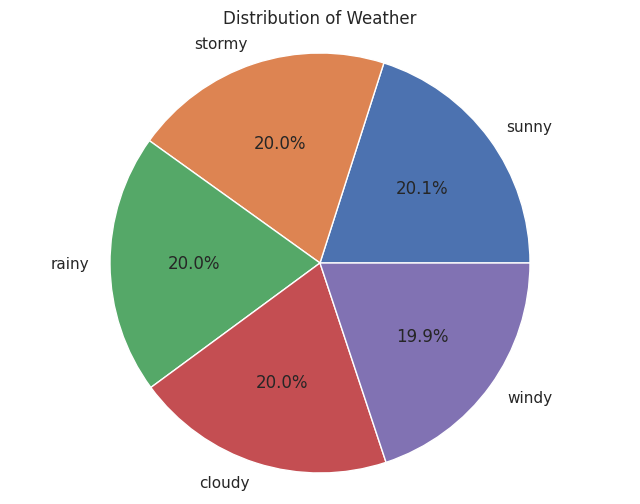

In [83]:
# Value counts for Weather Condition
weather_counts = df['Weather'].value_counts()

# Plotting the pie chart
plt.figure(figsize=(8, 6))
plt.pie(weather_counts, labels=weather_counts.index, autopct='%1.1f%%', startangle=0)
plt.title('Distribution of Weather')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


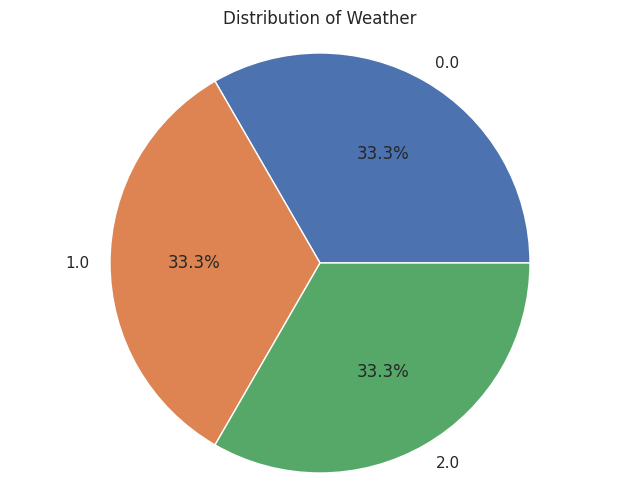

In [84]:
# Value counts for Traffic Condition
traffic_condition_counts = df['Traffic Condition'].value_counts()

# Plotting the pie chart
plt.figure(figsize=(8, 6))
plt.pie(traffic_condition_counts, labels=traffic_condition_counts.index, autopct='%1.1f%%', startangle=0)
plt.title('Distribution of Weather')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


In [85]:
pivot_table = df.pivot_table(index='year', values='fare_amount', aggfunc='mean')
pivot_table

,fare_amount
year,
2009,9.054914
2010,9.242729
2011,9.384978
2012,9.950769
2013,11.201474
2014,11.474058
2015,11.439675


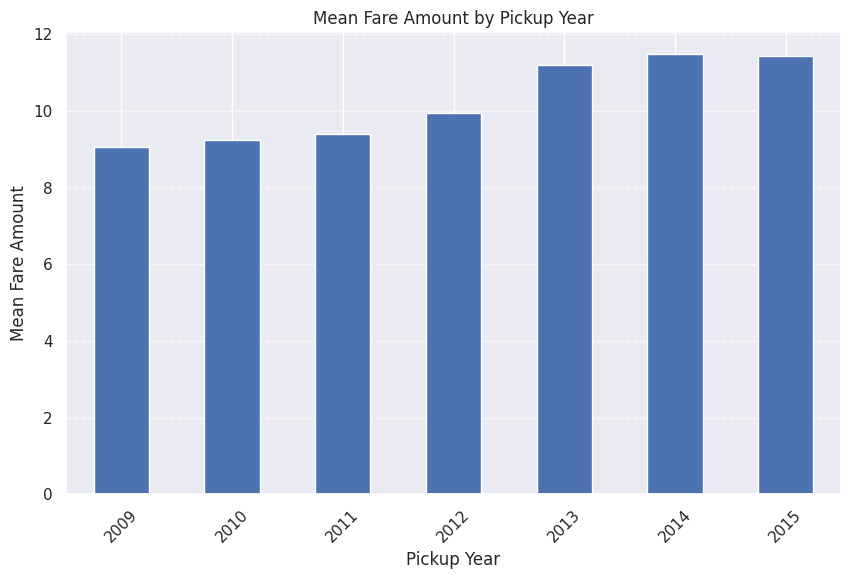

In [86]:
# Grouping mean fare_amount by pickup_year
fare_by_year = df.groupby('year')['fare_amount'].mean()

# Plotting the results
fare_by_year.plot(kind='bar', figsize=(10, 6))
plt.title('Mean Fare Amount by Pickup Year')
plt.xlabel('Pickup Year')
plt.ylabel('Mean Fare Amount')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


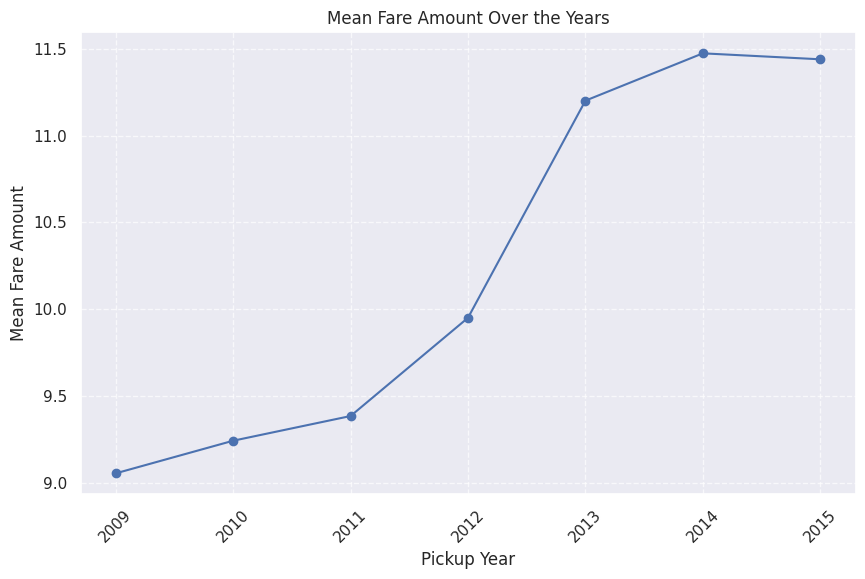

In [87]:
# Plotting the line chart
plt.figure(figsize=(10, 6))
plt.plot(pivot_table.index, pivot_table['fare_amount'], marker='o', linestyle='-')
plt.title('Mean Fare Amount Over the Years')
plt.xlabel('Pickup Year')
plt.ylabel('Mean Fare Amount')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(pivot_table.index, rotation=45)  # Rotate x-axis labels for better readability
plt.show()

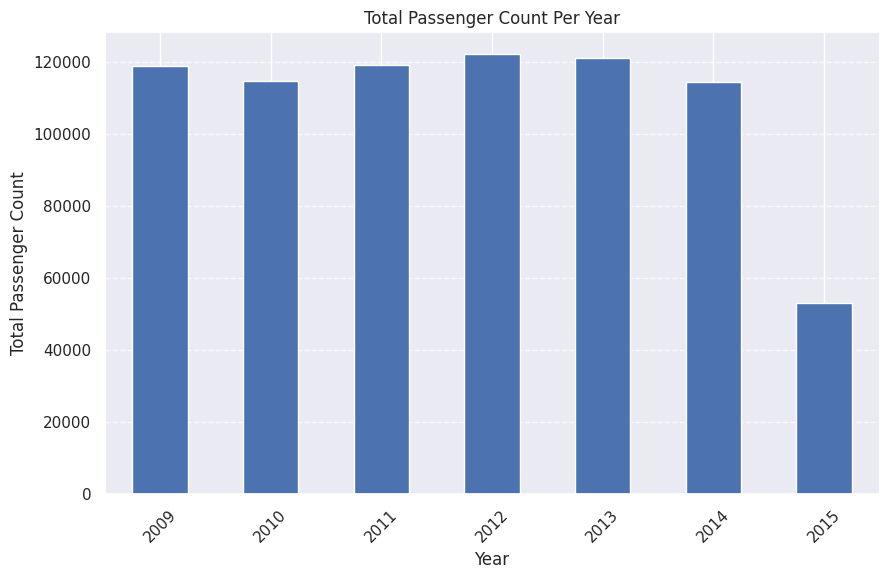

In [88]:
# Grouping data by year and calculating the total passenger count
yearly_count = df.groupby('year')['passenger_count'].sum()

# Plotting the bar chart
plt.figure(figsize=(10, 6))
yearly_count.plot(kind='bar')
plt.title('Total Passenger Count Per Year')
plt.xlabel('Year')
plt.ylabel('Total Passenger Count')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
